In [2]:
import pandas as pd
print("pandas is working!")

pandas is working!


In [4]:
df = pd.read_csv('/Users/rohitgurjar/Downloads/PS_20174392719_1491204439457_log.csv')
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [5]:
df['isFraud'].value_counts()

isFraud
0    6354407
1       8213
Name: count, dtype: int64

In [6]:
df.groupby('type')['isFraud'].sum()

type
CASH_IN        0
CASH_OUT    4116
DEBIT          0
PAYMENT        0
TRANSFER    4097
Name: isFraud, dtype: int64

In [7]:
fraud_df = df[df['isFraud'] == 1]
fraud_df[['type', 'amount', 'oldbalanceOrg', 'newbalanceOrig']].head(10)

,type,amount,oldbalanceOrg,newbalanceOrig
2,TRANSFER,181.00,181.00,0.0
3,CASH_OUT,181.00,181.00,0.0
251,TRANSFER,2806.00,2806.00,0.0
252,CASH_OUT,2806.00,2806.00,0.0
680,TRANSFER,20128.00,20128.00,0.0
681,CASH_OUT,20128.00,20128.00,0.0
724,CASH_OUT,416001.33,0.00,0.0
969,TRANSFER,1277212.77,1277212.77,0.0
970,CASH_OUT,1277212.77,1277212.77,0.0
1115,TRANSFER,35063.63,35063.63,0.0


In [8]:
df['orig_emptied'] = (df['newbalanceOrig'] == 0) & (df['oldbalanceOrg'] > 0)
df[df['isFraud'] == 1]['orig_emptied'].value_counts()

orig_emptied
True     8012
False     201
Name: count, dtype: int64

In [9]:
df['amount_to_balance_ratio'] = df['amount'] / (df['oldbalanceOrg'] + 1)
df[df['isFraud'] == 1]['amount_to_balance_ratio'].describe()

count    8.213000e+03
mean     1.161967e+03
std      3.229715e+04
min      0.000000e+00
25%      9.999913e-01
50%      9.999976e-01
75%      9.999993e-01
max      1.933921e+06
Name: amount_to_balance_ratio, dtype: float64

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# Select features (inputs) and label (answer)
features = ['amount', 'oldbalanceOrg', 'newbalanceOrig', 'orig_emptied', 'amount_to_balance_ratio']
X = df[features]
y = df['isFraud']

# Split data: 80% to train the model, 20% to test how well it learned
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))

Training rows: 5090096
Testing rows: 1272524


In [11]:
model = RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)
print("Model trained!")

Model trained!


In [12]:
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred, target_names=['Not Fraud', 'Fraud']))

              precision    recall  f1-score   support

   Not Fraud       1.00      1.00      1.00   1270904
       Fraud       0.99      1.00      0.99      1620

    accuracy                           1.00   1272524
   macro avg       1.00      1.00      1.00   1272524
weighted avg       1.00      1.00      1.00   1272524



In [13]:
importances = pd.Series(model.feature_importances_, index=features)
importances.sort_values(ascending=False)

amount_to_balance_ratio    0.642438
oldbalanceOrg              0.112718
newbalanceOrig             0.107302
orig_emptied               0.102704
amount                     0.034839
dtype: float64

In [14]:
import joblib

joblib.dump(model, 'muleshield_model.pkl')
print("Model saved!")

Model saved!


In [15]:
import os
print(os.path.getsize('muleshield_model.pkl') / (1024*1024), "MB")

0.5647821426391602 MB


In [16]:
fraud_probabilities = model.predict_proba(X_test)[:, 1]
fraud_probabilities[:10]

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

In [17]:
def get_risk_tier(probability):
    if probability < 0.30:
        return "LOW"
    elif probability < 0.70:
        return "MEDIUM"
    else:
        return "HIGH"

def get_auth_requirement(tier):
    if tier == "LOW":
        return "PIN only"
    elif tier == "MEDIUM":
        return "PIN + OTP"
    else:
        return "PIN + Face Recognition"

# Test it on our fraud probabilities
risk_tiers = [get_risk_tier(p) for p in fraud_probabilities]
pd.Series(risk_tiers).value_counts()

LOW       1270892
HIGH         1622
MEDIUM         10
Name: count, dtype: int64

In [18]:
def evaluate_transaction(amount, oldbalanceOrg, newbalanceOrig):
    orig_emptied = 1 if (newbalanceOrig == 0 and oldbalanceOrg > 0) else 0
    amount_to_balance_ratio = amount / (oldbalanceOrg + 1)
    
    input_data = pd.DataFrame([{
        'amount': amount,
        'oldbalanceOrg': oldbalanceOrg,
        'newbalanceOrig': newbalanceOrig,
        'orig_emptied': orig_emptied,
        'amount_to_balance_ratio': amount_to_balance_ratio
    }])
    
    probability = model.predict_proba(input_data)[0][1]
    tier = get_risk_tier(probability)
    auth = get_auth_requirement(tier)
    
    print(f"Transaction amount: ₹{amount}")
    print(f"Fraud probability: {probability:.2%}")
    print(f"Risk tier: {tier}")
    print(f"Authentication required: {auth}")

# Test with a normal-looking transaction
evaluate_transaction(amount=500, oldbalanceOrg=50000, newbalanceOrig=49500)

Transaction amount: ₹500
Fraud probability: 0.00%
Risk tier: LOW
Authentication required: PIN only


In [19]:
# Test with a suspicious mule-pattern transaction: large amount, account drained to zero
evaluate_transaction(amount=45000, oldbalanceOrg=45000, newbalanceOrig=0)

Transaction amount: ₹45000
Fraud probability: 100.00%
Risk tier: HIGH
Authentication required: PIN + Face Recognition


In [20]:
!pip3 install opencv-python

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 34.8/34.8 MB 10.6 MB/s  0:00:03m0:00:0100:01

[notice] A new release of pip is available: 26.1.1 -> 26.2
[notice] To update, run: pip3 install --upgrade pip


In [21]:
import cv2
print("OpenCV version:", cv2.__version__)

OpenCV version: 5.0.0


In [22]:
cap = cv2.VideoCapture(0)
ret, frame = cap.read()
cap.release()

if ret:
    print("Camera works! Frame captured.")
    print("Frame shape:", frame.shape)
else:
    print("Could not access camera.")

Could not access camera.


OpenCV: not authorized to capture video (status 0), requesting...
OpenCV: camera failed to properly initialize!


In [23]:
cap = cv2.VideoCapture(0)
ret, frame = cap.read()
cap.release()

if ret:
    print("Camera works! Frame captured.")
    print("Frame shape:", frame.shape)
else:
    print("Could not access camera.")

Camera works! Frame captured.
Frame shape: (720, 1280, 3)


Matplotlib is building the font cache; this may take a moment.


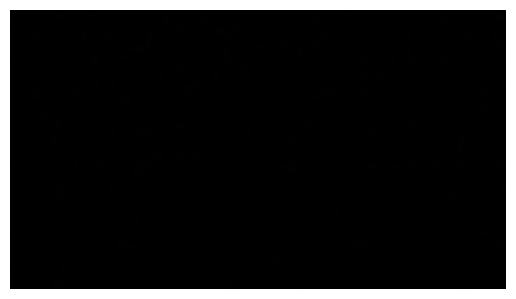

In [24]:
import matplotlib.pyplot as plt

cap = cv2.VideoCapture(0)
ret, frame = cap.read()
cap.release()

# OpenCV captures in BGR color order, but matplotlib expects RGB — so we convert
frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

plt.imshow(frame_rgb)
plt.axis('off')
plt.show()

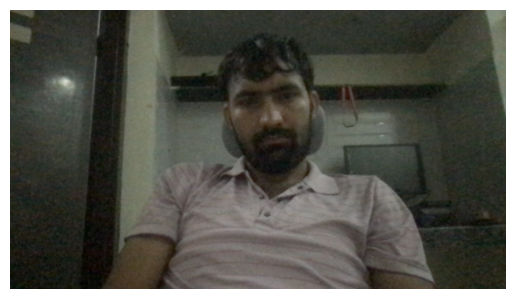

In [25]:
cap = cv2.VideoCapture(0)

# Warm-up: read and discard the first several frames
for i in range(10):
    ret, frame = cap.read()

cap.release()

frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
plt.imshow(frame_rgb)
plt.axis('off')
plt.show()

In [26]:
# Load OpenCV's built-in face detector
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')

# Convert to grayscale (face detection works better/faster on grayscale)
gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

# Detect faces
faces = face_cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5)

print(f"Number of faces detected: {len(faces)}")
print("Face locations (x, y, width, height):", faces)

AttributeError: module 'cv2' has no attribute 'CascadeClassifier'

In [27]:
# Check if 'data' submodule exists
print("Has 'data' attribute:", hasattr(cv2, 'data'))

# Search for anything related to face/cascade detection in this version
matches = [x for x in dir(cv2) if 'ascade' in x.lower() or 'face' in x.lower()]
print("Matching attributes:", matches)

Has 'data' attribute: True
Matching attributes: ['FACE_RECOGNIZER_SF_FR_COSINE', 'FACE_RECOGNIZER_SF_FR_NORM_L2', 'FaceDetectorYN', 'FaceDetectorYN_create', 'FaceRecognizerSF', 'FaceRecognizerSF_FR_COSINE', 'FaceRecognizerSF_FR_NORM_L2', 'FaceRecognizerSF_create', 'FontFace']


In [28]:
!pip3 uninstall opencv-python -y
!pip3 install opencv-python==4.9.0.80

Found existing installation: opencv-python 5.0.0.93
Uninstalling opencv-python-5.0.0.93:
  Successfully uninstalled opencv-python-5.0.0.93
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.7/55.7 MB 6.3 MB/s  0:00:08m0:00:0100:01m

[notice] A new release of pip is available: 26.1.1 -> 26.2
[notice] To update, run: pip3 install --upgrade pip


In [29]:
import pandas as pd
import cv2
import joblib

model = joblib.load('muleshield_model.pkl')
print("OpenCV version:", cv2.__version__)

OpenCV version: 5.0.0


In [1]:
import pandas as pd
import cv2
import joblib

model = joblib.load('muleshield_model.pkl')
print("OpenCV version:", cv2.__version__)


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.5.1 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 203, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/traitlets/config/application.py", line 1080, in launch_instance
    app.start()
  File "/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/ipyk

AttributeError: _ARRAY_API not found

ImportError: numpy.core.multiarray failed to import

In [2]:
!pip3 install "opencv-python>=4.10,<5"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 33.1/33.1 MB 6.5 MB/s  0:00:05 eta 0:00:01
  Attempting uninstall: opencv-python
    Found existing installation: opencv-python 4.9.0.80
    Uninstalling opencv-python-4.9.0.80:
      Successfully uninstalled opencv-python-4.9.0.80

[notice] A new release of pip is available: 26.1.1 -> 26.2
[notice] To update, run: pip3 install --upgrade pip


In [3]:
import cv2
print("OpenCV version:", cv2.__version__)
print("Has CascadeClassifier:", hasattr(cv2, 'CascadeClassifier'))


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.5.1 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 203, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/traitlets/config/application.py", line 1080, in launch_instance
    app.start()
  File "/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/ipyk

AttributeError: _ARRAY_API not found

ImportError: numpy.core.multiarray failed to import

In [4]:
!pip3 install --no-cache-dir --force-reinstall numpy opencv-python

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.7/6.7 MB 12.9 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 34.8/34.8 MB 7.6 MB/s  0:00:04m0:00:0100:01m
  Attempting uninstall: numpy
    Found existing installation: numpy 2.5.1
    Uninstalling numpy-2.5.1:
      Successfully uninstalled numpy-2.5.1━━━━━━ 0/2 [numpy]
  Attempting uninstall: opencv-python━━━━━━━━━━━ 0/2 [numpy]
    Found existing installation: opencv-python 4.14.0.942 [numpy]
    Uninstalling opencv-python-4.14.0.94:━━━ 0/2 [numpy]
      Successfully uninstalled opencv-python-4.14.0.940/2 [numpy]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [opencv-python]0m [opencv-python]

[notice] A new release of pip is available: 26.1.1 -> 26.2
[notice] To update, run: pip3 install --upgrade pip


In [1]:
import cv2
print("OpenCV version:", cv2.__version__)
print("Has CascadeClassifier:", hasattr(cv2, 'CascadeClassifier'))

OpenCV version: 5.0.0
Has CascadeClassifier: False


In [2]:
!pip3 install --no-cache-dir "opencv-python>=4.10,<5"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 33.1/33.1 MB 8.4 MB/s  0:00:04m0:00:0100:01m
  Attempting uninstall: opencv-python
    Found existing installation: opencv-python 5.0.0.93
    Uninstalling opencv-python-5.0.0.93:
      Successfully uninstalled opencv-python-5.0.0.93

[notice] A new release of pip is available: 26.1.1 -> 26.2
[notice] To update, run: pip3 install --upgrade pip


In [3]:
import cv2
print("OpenCV version:", cv2.__version__)
print("Has CascadeClassifier:", hasattr(cv2, 'CascadeClassifier'))

OpenCV version: 5.0.0
Has CascadeClassifier: False


In [1]:
import cv2
print("OpenCV version:", cv2.__version__)
print("Has CascadeClassifier:", hasattr(cv2, 'CascadeClassifier'))

OpenCV version: 4.14.0
Has CascadeClassifier: True


In [2]:
import cv2
print("OpenCV version:", cv2.__version__)
print("Has CascadeClassifier:", hasattr(cv2, 'CascadeClassifier'))

OpenCV version: 4.14.0
Has CascadeClassifier: True


In [3]:
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')

cap = cv2.VideoCapture(0)
for i in range(10):  # warm-up
    ret, frame = cap.read()
cap.release()

gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
faces = face_cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5)

print(f"Number of faces detected: {len(faces)}")
print("Face locations (x, y, width, height):", faces)

Number of faces detected: 0
Face locations (x, y, width, height): ()


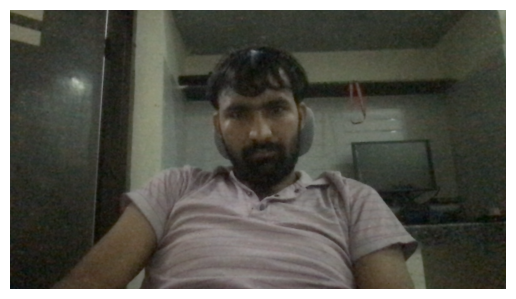

In [4]:
import matplotlib.pyplot as plt

frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
plt.imshow(frame_rgb)
plt.axis('off')
plt.show()

In [5]:
print("Cascade file path:", cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')
print("Classifier is empty (failed to load):", face_cascade.empty())

Cascade file path: /Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/cv2/data/haarcascade_frontalface_default.xml
Classifier is empty (failed to load): False


In [6]:
faces = face_cascade.detectMultiScale(
    gray,
    scaleFactor=1.05,
    minNeighbors=3,
    minSize=(30, 30)
)

print(f"Number of faces detected: {len(faces)}")
print("Face locations:", faces)

Number of faces detected: 1
Face locations: [[510 162 268 268]]


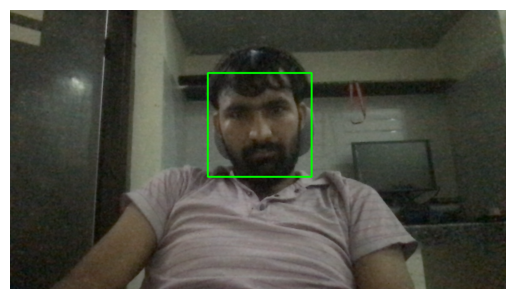

In [7]:
frame_with_box = frame.copy()

for (x, y, w, h) in faces:
    cv2.rectangle(frame_with_box, (x, y), (x+w, y+h), (0, 255, 0), 3)

frame_with_box_rgb = cv2.cvtColor(frame_with_box, cv2.COLOR_BGR2RGB)
plt.imshow(frame_with_box_rgb)
plt.axis('off')
plt.show()

In [8]:
def check_face_verification():
    """Simulates the 'PIN + Face Recognition' step for HIGH risk transactions."""
    face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')
    
    cap = cv2.VideoCapture(0)
    for i in range(10):
        ret, frame = cap.read()
    cap.release()
    
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    faces = face_cascade.detectMultiScale(gray, scaleFactor=1.05, minNeighbors=3, minSize=(30, 30))
    
    if len(faces) > 0:
        print("✅ Face verified — transaction approved")
        return True
    else:
        print("❌ No face detected — transaction blocked")
        return False

# Test it
check_face_verification()

✅ Face verified — transaction approved


True

In [9]:
def evaluate_transaction_with_auth(amount, oldbalanceOrg, newbalanceOrig):
    orig_emptied = 1 if (newbalanceOrig == 0 and oldbalanceOrg > 0) else 0
    amount_to_balance_ratio = amount / (oldbalanceOrg + 1)
    
    input_data = pd.DataFrame([{
        'amount': amount,
        'oldbalanceOrg': oldbalanceOrg,
        'newbalanceOrig': newbalanceOrig,
        'orig_emptied': orig_emptied,
        'amount_to_balance_ratio': amount_to_balance_ratio
    }])
    
    probability = model.predict_proba(input_data)[0][1]
    tier = get_risk_tier(probability)
    auth = get_auth_requirement(tier)
    
    print(f"Transaction amount: ₹{amount}")
    print(f"Fraud probability: {probability:.2%}")
    print(f"Risk tier: {tier}")
    print(f"Authentication required: {auth}")
    print("-" * 40)
    
    if tier == "HIGH":
        print("⚠️ High risk detected — triggering face verification...")
        approved = check_face_verification()
        if approved:
            print("✅ Transaction ALLOWED (face verified)")
        else:
            print("🚫 Transaction BLOCKED (no face detected)")
    else:
        print(f"✅ Transaction ALLOWED ({auth})")

# The full demo: a suspicious mule-pattern transaction
evaluate_transaction_with_auth(amount=45000, oldbalanceOrg=45000, newbalanceOrig=0)

NameError: name 'pd' is not defined

In [10]:
import pandas as pd
import joblib

# Reload the model
model = joblib.load('muleshield_model.pkl')

# Redefine the tier functions
def get_risk_tier(probability):
    if probability < 0.30:
        return "LOW"
    elif probability < 0.70:
        return "MEDIUM"
    else:
        return "HIGH"

def get_auth_requirement(tier):
    if tier == "LOW":
        return "PIN only"
    elif tier == "MEDIUM":
        return "PIN + OTP"
    else:
        return "PIN + Face Recognition"

print("Everything reloaded!")

Everything reloaded!


In [11]:
def evaluate_transaction_with_auth(amount, oldbalanceOrg, newbalanceOrig):
    orig_emptied = 1 if (newbalanceOrig == 0 and oldbalanceOrg > 0) else 0
    amount_to_balance_ratio = amount / (oldbalanceOrg + 1)
    
    input_data = pd.DataFrame([{
        'amount': amount,
        'oldbalanceOrg': oldbalanceOrg,
        'newbalanceOrig': newbalanceOrig,
        'orig_emptied': orig_emptied,
        'amount_to_balance_ratio': amount_to_balance_ratio
    }])
    
    probability = model.predict_proba(input_data)[0][1]
    tier = get_risk_tier(probability)
    auth = get_auth_requirement(tier)
    
    print(f"Transaction amount: ₹{amount}")
    print(f"Fraud probability: {probability:.2%}")
    print(f"Risk tier: {tier}")
    print(f"Authentication required: {auth}")
    print("-" * 40)
    
    if tier == "HIGH":
        print("⚠️ High risk detected — triggering face verification...")
        approved = check_face_verification()
        if approved:
            print("✅ Transaction ALLOWED (face verified)")
        else:
            print("🚫 Transaction BLOCKED (no face detected)")
    else:
        print(f"✅ Transaction ALLOWED ({auth})")

# The full demo: a suspicious mule-pattern transaction
evaluate_transaction_with_auth(amount=45000, oldbalanceOrg=45000, newbalanceOrig=0)

Transaction amount: ₹45000
Fraud probability: 100.00%
Risk tier: HIGH
Authentication required: PIN + Face Recognition
----------------------------------------
⚠️ High risk detected — triggering face verification...
✅ Face verified — transaction approved
✅ Transaction ALLOWED (face verified)


In [12]:
# LOW risk: small, normal transaction — should NOT trigger the camera at all
evaluate_transaction_with_auth(amount=500, oldbalanceOrg=50000, newbalanceOrig=49500)

Transaction amount: ₹500
Fraud probability: 0.00%
Risk tier: LOW
Authentication required: PIN only
----------------------------------------
✅ Transaction ALLOWED (PIN only)


In [13]:
# HIGH risk transaction, but we'll cover the camera to simulate no face present
print("Cover your camera now! You have 3 seconds...")
import time
time.sleep(3)

evaluate_transaction_with_auth(amount=45000, oldbalanceOrg=45000, newbalanceOrig=0)

Cover your camera now! You have 3 seconds...
Transaction amount: ₹45000
Fraud probability: 100.00%
Risk tier: HIGH
Authentication required: PIN + Face Recognition
----------------------------------------
⚠️ High risk detected — triggering face verification...
❌ No face detected — transaction blocked
🚫 Transaction BLOCKED (no face detected)


In [14]:
!pip3 install streamlit --no-cache-dir

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.4/10.4 MB 9.3 MB/s  0:00:01eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 797.6/797.6 kB 14.7 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.7/36.7 MB 10.8 MB/s  0:00:03m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 8.1 MB/s  0:00:01 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15/15 [streamlit]15 [streamlit]tipart]

[notice] A new release of pip is available: 26.1.1 -> 26.2
[notice] To update, run: pip3 install --upgrade pip


In [15]:
%%writefile muleshield_app.py
import streamlit as st
import pandas as pd
import joblib
import cv2

st.set_page_config(page_title="MuleShield", page_icon="🛡️")

st.title("🛡️ MuleShield")
st.caption("AI-powered mule account fraud prevention")

model = joblib.load('muleshield_model.pkl')

def get_risk_tier(probability):
    if probability < 0.30:
        return "LOW"
    elif probability < 0.70:
        return "MEDIUM"
    else:
        return "HIGH"

def get_auth_requirement(tier):
    if tier == "LOW":
        return "PIN only"
    elif tier == "MEDIUM":
        return "PIN + OTP"
    else:
        return "PIN + Face Recognition"

def check_face_verification():
    face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')
    cap = cv2.VideoCapture(0)
    for i in range(10):
        ret, frame = cap.read()
    cap.release()
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    faces = face_cascade.detectMultiScale(gray, scaleFactor=1.05, minNeighbors=3, minSize=(30, 30))
    return len(faces) > 0, frame, faces

st.subheader("Enter Transaction Details")
amount = st.number_input("Transaction Amount (₹)", min_value=0, value=500, step=100)
oldbalance = st.number_input("Account Balance Before (₹)", min_value=0, value=50000, step=100)
newbalance = st.number_input("Account Balance After (₹)", min_value=0, value=49500, step=100)

if st.button("🔍 Evaluate Transaction", type="primary"):
    orig_emptied = 1 if (newbalance == 0 and oldbalance > 0) else 0
    ratio = amount / (oldbalance + 1)

    input_data = pd.DataFrame([{
        'amount': amount,
        'oldbalanceOrg': oldbalance,
        'newbalanceOrig': newbalance,
        'orig_emptied': orig_emptied,
        'amount_to_balance_ratio': ratio
    }])

    probability = model.predict_proba(input_data)[0][1]
    tier = get_risk_tier(probability)
    auth = get_auth_requirement(tier)

    col1, col2 = st.columns(2)
    col1.metric("Fraud Probability", f"{probability:.1%}")
    col2.metric("Risk Tier", tier)

    st.info(f"**Authentication required:** {auth}")

    if tier == "HIGH":
        st.warning("⚠️ High risk detected — verifying face...")
        with st.spinner("Checking webcam for live face..."):
            verified, frame, faces = check_face_verification()

        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        for (x, y, w, h) in faces:
            cv2.rectangle(frame_rgb, (x, y), (x+w, y+h), (0, 255, 0), 3)
        st.image(frame_rgb, caption="Live camera check", width=400)

        if verified:
            st.success("✅ Face verified — Transaction ALLOWED")
        else:
            st.error("🚫 No face detected — Transaction BLOCKED")
    else:
        st.success(f"✅ Transaction ALLOWED ({auth})")

Writing muleshield_app.py


In [16]:
import subprocess
process = subprocess.Popen(
    ["streamlit", "run", "muleshield_app.py", "--server.headless", "true"],
    stdout=subprocess.DEVNULL,
    stderr=subprocess.DEVNULL
)
print("Streamlit launched! PID:", process.pid)

Streamlit launched! PID: 2806


In [17]:
%%writefile requirements.txt
streamlit
pandas
scikit-learn
opencv-python-headless
joblib

Writing requirements.txt


In [18]:
%%writefile README.md
# 🛡️ MuleShield

**AI-driven step-up authentication to stop mule account fraud in digital payments.**

Mule accounts let scammers launder stolen money by routing it through accounts they don't own — because today's authentication (PIN, OTP) only proves someone *knows* a secret, not that the real account holder is present. MuleShield closes that gap.

## How it works

1. **Risk scoring** — a Random Forest model, trained on 6M+ real transaction records, scores every transaction for mule-fraud patterns (specifically: sudden account drainage and near-100% balance transfers).
2. **Tiered authentication** — low-risk transactions pass with a PIN, medium-risk gets an OTP challenge, and high-risk transactions trigger live face verification — so security scales with risk instead of annoying every user.
3. **Live face verification** — high-risk transactions activate the device camera and require a real, present face before approving the transfer, using OpenCV face detection.

## Tech stack

Python, scikit-learn, pandas, OpenCV, Streamlit

## Run it locally

```bash
pip install -r requirements.txt
streamlit run muleshield_app.py
```

## Team / Track

Built solo for Smart India Hackathon 2026 — Blockchain & Cybersecurity theme.

Writing README.md
